<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [4]:
#Importation du fichier population.csv
population = pd.read_csv('./DAN-P4-FAO/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('./DAN-P4-FAO/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('./DAN-P4-FAO/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv ('./DAN-P4-FAO/sous_nutrition.csv')

web_nut = pd.read_excel('./DAN-P4-FAO/web.xlsx')

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [41]:
#Consulter le nombre de colonnes
nombre_colonnes = population.shape[1]
print(f"Nombre de colonnes : {nombre_colonnes}")

#La nature des données dans chacune des colonnes
nature_donnees = population.dtypes
print("Nature des données dans chaque colonne :")
print(nature_donnees)

#Le nombre de valeurs présentes dans chacune des colonnes
nombre_valeurs = population.count()
print("Nombre de valeurs présentes dans chaque colonne :")
print(nombre_valeurs)



Nombre de colonnes : 3
Nature des données dans chaque colonne :
Zone       object
Année       int64
Valeur    float64
dtype: object
Nombre de valeurs présentes dans chaque colonne :
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [42]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [43]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur'] * 1000


# Afficher les premières lignes pour vérifier
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [44]:
#Affichage les 5 premières lignes de la table
population.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [45]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns = {'Valeur' : 'Population'}) 

# Afficher les premières lignes pour vérifier( répéter par le suivant )
print(population.head())

          Zone  Année  Population
0  Afghanistan   2013  32269589.0
1  Afghanistan   2014  33370794.0
2  Afghanistan   2015  34413603.0
3  Afghanistan   2016  35383032.0
4  Afghanistan   2017  36296113.0


In [46]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [47]:
#Afficher les dimensions du dataset
dimensions = dispo_alimentaire.shape
print(f"Dimensions du dataset : {dimensions}")
print(f"Nombre de lignes : {dimensions[0]}")
print(f"Nombre de colonnes : {dimensions[1]}")


Dimensions du dataset : (15605, 18)
Nombre de lignes : 15605
Nombre de colonnes : 18


In [48]:
#Consulter le nombre de colonnes
print(f"Nombre de colonnes : {dimensions[1]}")

Nombre de colonnes : 18


In [49]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [50]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)
dispo_alimentaire.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [51]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg

dispo_alimentaire[['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité',
                                                 'Importations - Quantité','Nourriture','Pertes','Production','Semences','Traitement', 
                                                 'Variation de stock']] = dispo_alimentaire[['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité',
                                                 'Importations - Quantité','Nourriture','Pertes','Production','Semences','Traitement', 
                                                 'Variation de stock']] * 1000

In [52]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [53]:
#Afficher les dimensions du dataset
dimension = aide_alimentaire.shape

print(f"Dimensions du dataset : {dimension[0]} lignes et {dimension[1]} colonnes")



Dimensions du dataset : 1475 lignes et 4 colonnes


In [54]:
#Consulter le nombre de colonnes
dimension = aide_alimentaire.shape[1]

print(f"Nombre de colonnes dans le dataset : {dimension}")


Nombre de colonnes dans le dataset : 4


In [55]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [56]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire =aide_alimentaire.rename(columns = {'Pays bénéficiaire': 'Zone'})
aide_alimentaire.head()


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [57]:
#Vérification de type des données de la colonne 'Valeur'


print(f"Type de données de la colonne 'Valeur' : {aide_alimentaire['Valeur'].dtype}")


Type de données de la colonne 'Valeur' : int64


In [58]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur']= aide_alimentaire['Valeur'] * 1000



In [59]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [60]:
#Afficher les dimensions du dataset
dimension = sous_nutrition.shape

print(f"Dimensions du dataset : {dimension[0]} lignes et {dimension[1]} colonnes")


Dimensions du dataset : 1218 lignes et 3 colonnes


In [61]:
#Consulter le nombre de colonnes

print(f"Nombre de colonnes dans le dataset : {nombre_colonnes}")


Nombre de colonnes dans le dataset : 3


In [62]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [63]:
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

ValueError: Unable to parse string "<0.1" at position 60

In [64]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')

sous_nutrition.head()

#Valeur avec '<0.1' comme valeur 

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [65]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition.fillna(0, inplace = True)


In [66]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns = {'Valeur': 'sous_nutrition'})

sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [67]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] = sous_nutrition['sous_nutrition'] * 1000000


In [68]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [69]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition,
#en ciblant l'année 2017


#Filtrer pour l'année 2017

Population_2017 = population[population['Année'] == 2017]
Sous_nutrition_2017 = sous_nutrition[sous_nutrition['Année'] == "2016-2018"]

    
Jointure_2017 = pd.merge(Population_2017, Sous_nutrition_2017, on='Zone')


In [70]:
#Affichage du dataset
Jointure_2017

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0
...,...,...,...,...,...
198,Venezuela (République bolivarienne du),2017,29402484.0,2016-2018,8000000.0
199,Viet Nam,2017,94600648.0,2016-2018,6500000.0
200,Yémen,2017,27834819.0,2016-2018,0.0
201,Zambie,2017,16853599.0,2016-2018,0.0


In [71]:
#Calcul et affichage du nombre de personnes en état de sous nutrition

# Calcul des totaux
total_population = Jointure_2017['Population'].sum()
total_sous_nutrition = Jointure_2017['sous_nutrition'].sum()

# Calcul du pourcentage
pourcentage_sous_nutrition = (total_sous_nutrition / total_population) * 100

# Calcul du total de personnes en état de sous-nutrition
#total_sous_nutrition = Jointure_2017['sous_nutrition'].sum() ( 10 et 11 à supprimer )

# Affichage du résultat
print(f"Le nombre total de personnes en état de sous-nutrition est : {total_sous_nutrition:.0f}")


# Affichage du pourcentage
print(f"Le pourcentage de personnes en état de sous-nutrition est : {pourcentage_sous_nutrition:.2f}%")



Le nombre total de personnes en état de sous-nutrition est : 535700000
Le pourcentage de personnes en état de sous-nutrition est : 7.10%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [72]:
#Combien mange en moyenne un être humain ? Source => https://www.msdmanuals.com/fr/accueil/multimedia/table/nombre-de-calories-n%C3%A9cessaires-estim%C3%A9-dapr%C3%A8s-l%C3%A2ge-le-sexe-et-le-niveau-dactivit%C3%A9-physique

kcal_moyen =2250

In [73]:
dispo_alimentaire1 = dispo_alimentaire.merge(population.loc[population['Année'] == 2017,["Zone", "Population"]],
                                            on='Zone')

In [74]:
# Affichage du nouveau dataframe

dispo_alimentaire1

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000.0,0.0,0.0,3000.0,0.0,2000.0,0.0,0.0,0.0,636039.0
15412,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,636039.0
15413,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0
15414,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0


In [75]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

dispo_alimentaire1['dispo_kcal'] = dispo_alimentaire1['Disponibilité alimentaire (Kcal/personne/jour)'] * dispo_alimentaire1['Population'] * 365


dispo_alimentaire1



,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,36296113.0,6.624041e+10
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0,1.324808e+10
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000.0,0.0,0.0,3000.0,0.0,2000.0,0.0,0.0,0.0,636039.0,1.044694e+10
15412,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,636039.0,2.553697e+09
15413,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00
15414,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00


In [76]:
disponibilité_alimentaire_mondial = dispo_alimentaire1['dispo_kcal'].sum()

print(f"La disponibilité alimentaire mondial est  : {disponibilité_alimentaire_mondial:.0f}")



La disponibilité alimentaire mondial est  : 7635429388975815


In [77]:
#Calcul du nombre d'humains pouvant être nourris 

Nombre_humains = (disponibilité_alimentaire_mondial/(kcal_moyen*365))

print(f"Le Nombre d'humains pouvant être nourris est : {Nombre_humains:.2f}")



proportion = (Nombre_humains/total_population)*100

print(f"La proportion est : {proportion:.2f}%")



Le Nombre d'humains pouvant être nourris est : 9297326501.04
La proportion est : 123.24%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [78]:
#Transfert des données avec les végétaux dans un nouveau dataframe


dispo_vegetaux = dispo_alimentaire1[dispo_alimentaire1.loc[:, "Origine"]== "vegetale"]

dispo_vegetaux



,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,36296113.0,1.324808e+10
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000.0,0.0,3000.0,3000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Îles Salomon,Sésame,vegetale,0.0,0.0,0.0,0.01,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00
15407,Îles Salomon,Thé,vegetale,0.0,0.0,0.0,0.17,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00
15408,Îles Salomon,Tomates,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00
15414,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00


In [79]:
#Calcul du nombre de kcal disponible pour les végétaux

nbr_kcal_vegetal = dispo_vegetaux.loc[:, "dispo_kcal"].sum()

print(f"Nombre total de calories des végétaux disponibles : {nbr_kcal_vegetal} kcal")


Nombre total de calories des végétaux disponibles : 6300178937197865.0 kcal


In [80]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux

humain_nourris_vegetal = nbr_kcal_vegetal / (kcal_moyen * 365)

proportion_vegetale = ((humain_nourris_vegetal/total_population)*100).round(2)


print(f"Nombre d'humains pouvant être nourris avec les végétaux : {humain_nourris_vegetal:.2f}")

print(f"Proportion de la population nourrie par les végétaux : {proportion_vegetale:.2f}%")


Nombre d'humains pouvant être nourris avec les végétaux : 7671450760.67
Proportion de la population nourrie par les végétaux : 101.69%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [81]:
#Calcul de la disponibilité totale

dispo_totale = dispo_alimentaire1.loc[:, "Disponibilité intérieure"].sum()

print(f"La disponibilité total est : {dispo_totale:.0f}")



La disponibilité total est : 9733927000


In [82]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 

colonne=['Aliments pour animaux','Pertes','Nourriture', 'Semences', 'Traitement', 'Autres Utilisations']

sum_colonne = dispo_alimentaire1.loc[:, colonne].sum()

proportion_colonne = (sum_colonne/dispo_totale)*100

def proportion_fonction(proportion_colonne):
    for catregorie, proportion in proportion_colonne.items():
        print(f"{catregorie}: {proportion:2f} %")

proportion_fonction(proportion_colonne)


Aliments pour animaux: 13.232090 %
Pertes: 4.646460 %
Nourriture: 49.368821 %
Semences: 1.575079 %
Traitement: 22.453846 %
Autres Utilisations: 8.822452 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [83]:
#Création d'une liste avec toutes les variables

variable =dispo_alimentaire["Produit"].unique()


variable

array(['Abats Comestible', 'Agrumes, Autres', 'Aliments pour enfants',
       'Ananas', 'Bananes', 'Beurre, Ghee', 'Bière', 'Blé',
       'Boissons Alcooliques', 'Café', 'Coco (Incl Coprah)', 'Crème',
       'Céréales, Autres', 'Dattes', 'Edulcorants Autres',
       'Feve de Cacao', 'Fruits, Autres', 'Graines de coton',
       'Graines de tournesol', 'Graisses Animales Crue',
       'Huil Plantes Oleif Autr', 'Huile Graines de Coton',
       "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde',
       'Huile de Palme', 'Huile de Soja', 'Huile de Sésame',
       'Huile de Tournesol', 'Lait - Excl Beurre', 'Légumes, Autres',
       'Légumineuses Autres', 'Maïs', 'Miel', 'Millet', 'Miscellanees',
       'Noix', 'Oeufs', 'Olives', 'Oranges, Mandarines', 'Orge',
       'Plantes Oleiferes, Autre', 'Poissons Eau Douce', 'Poivre',
       'Pommes', 'Pommes de Terre', 'Raisin', 'Riz (Eq Blanchi)',
       'Sucre Eq Brut', 'Sucre, betterave', 'Sucre, canne', 'Sésame',
       'Thé', 'Toma

In [84]:
#Création d'un dataframe avec les informations uniquement pour ces céréales

liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

df_cereales = dispo_alimentaire[dispo_alimentaire.loc[:, "Produit"].isin(liste_cereales)]

display(df_cereales)


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15545,Îles Salomon,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15568,Îles Salomon,Maïs,vegetale,0.0,0.0,1.0,0.15,0.01,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15575,Îles Salomon,Orge,vegetale,0.0,0.0,0.0,0.07,0.00,0.01,1000.0,0.0,1000.0,0.0,0.0,0.0,0.0,1000.0,0.0
15591,Îles Salomon,Riz (Eq Blanchi),vegetale,0.0,12000.0,623.0,63.76,1.36,10.90,49000.0,0.0,47000.0,36000.0,1000.0,3000.0,0.0,0.0,0.0


In [85]:
#Affichage de la proportion d'alimentation animale

aliment_animaux_dispo = ((df_cereales.loc[:,"Aliments pour animaux"].sum())/ (df_cereales.loc[:,"Disponibilité intérieure"].sum()))*100

print(f"La disponibilité de l'alimentation animale est  : {aliment_animaux_dispo:.2f}")



La disponibilité de l'alimentation animale est  : 36.29


In [86]:
#Affichage de la proportion d'alimentation humaine

aliment_humain_dispo = ((df_cereales.loc[:,"Nourriture"].sum())/ (df_cereales.loc[:,"Disponibilité intérieure"].sum()))*100

print(f"La disponibilité de l'alimentation humaine est  : {aliment_humain_dispo:.2f}")


La disponibilité de l'alimentation humaine est  : 42.75


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [87]:
#Création de la colonne proportion par pays

# Calcul du pourcentage

pourcentage_sous_nutrition_par_pays = (Jointure_2017.loc[:, 'sous_nutrition'] / Jointure_2017.loc[:, 'Population']) * 100


Jointure_2017["proportion par pays"] = pourcentage_sous_nutrition_par_pays

Jointure_2017


,Zone,Année_x,Population,Année_y,sous_nutrition,proportion par pays
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,28.928718
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0,5.437666
2,Albanie,2017,2884169.0,2016-2018,100000.0,3.467203
3,Algérie,2017,41389189.0,2016-2018,1300000.0,3.140917
4,Allemagne,2017,82658409.0,2016-2018,0.0,0.000000
...,...,...,...,...,...,...
198,Venezuela (République bolivarienne du),2017,29402484.0,2016-2018,8000000.0,27.208586
199,Viet Nam,2017,94600648.0,2016-2018,6500000.0,6.870989
200,Yémen,2017,27834819.0,2016-2018,0.0,0.000000
201,Zambie,2017,16853599.0,2016-2018,0.0,0.000000


In [88]:
#affichage après trie des 10 pires pays
#Jointure_2017
#Pire_10_pays =  Jointure_2017["proportion par pays"]

# Affichage après tri des 10 pires pays
Pire_10_pays = Jointure_2017.nlargest(10, "proportion par pays")
Pire_10_pays


,Zone,Année_x,Population,Année_y,sous_nutrition,proportion par pays
78,Haïti,2017,10982366.0,2016-2018,5300000.0,48.259182
157,République populaire démocratique de Corée,2017,25429825.0,2016-2018,12000000.0,47.188685
108,Madagascar,2017,25570512.0,2016-2018,10500000.0,41.062924
103,Libéria,2017,4702226.0,2016-2018,1800000.0,38.279742
100,Lesotho,2017,2091534.0,2016-2018,800000.0,38.249438
183,Tchad,2017,15016753.0,2016-2018,5700000.0,37.957606
161,Rwanda,2017,11980961.0,2016-2018,4200000.0,35.055619
121,Mozambique,2017,28649018.0,2016-2018,9400000.0,32.810898
186,Timor-Leste,2017,1243258.0,2016-2018,400000.0,32.173531
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,28.928718


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [89]:
aide_alimentaire.head(5)

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


In [90]:
#calcul du total de l'aide alimentaire par pays

aide_2013 = aide_alimentaire[aide_alimentaire['Année'] >= 2013]

total_aide_alimentaire_par_pays = aide_2013.groupby('Zone')['Valeur'].sum().reset_index()



In [91]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire

top_10_pays = total_aide_alimentaire_par_pays.sort_values(by= 'Valeur', ascending = False).head(10)

top_10_pays


,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [92]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année


# Filtrer les données pour les années entre 2013 et 2016
aide_alimentaire_filtered = aide_alimentaire[(aide_alimentaire['Année'] >= 2013) & (aide_alimentaire['Année'] <= 2016)]

Plus_bénéficiés = aide_alimentaire_filtered[['Zone', 'Année', 'Valeur']].groupby(['Zone', 'Année']).sum().reset_index()

Plus_bénéficiés

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [93]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire


# Obtenir les 5 zones avec les valeurs les plus élevées
top_5_zones = Plus_bénéficiés.groupby('Zone')['Valeur'].sum().nlargest(5).index.tolist()

top_5_zones


['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [94]:
#On filtre sur le dataframe avec notre liste

filtered_data = Plus_bénéficiés[Plus_bénéficiés['Zone'].isin(top_5_zones)]

filtered_data


,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


In [95]:
# Affichage des pays avec l'aide alimentaire par année
filtered_data.rename(index=str, columns={"Valeur":"Aide alimentaire"}, inplace=True)

filtered_data

C:\Users\CLDB3278\AppData\Local\Temp\1\ipykernel_12620\193879035.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.rename(index=str, columns={"Valeur":"Aide alimentaire"}, inplace=True)


,Zone,Année,Aide alimentaire
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [96]:
#Calcul de la disponibilité en kcal par personne par jour par pays

dispo_par_pays =  dispo_alimentaire.groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"].sum()

dispo_par_pays


Zone
Afghanistan              2087.0
Afrique du Sud           3020.0
Albanie                  3188.0
Algérie                  3293.0
Allemagne                3503.0
                          ...  
Émirats arabes unis      3275.0
Équateur                 2346.0
États-Unis d'Amérique    3682.0
Éthiopie                 2129.0
Îles Salomon             2383.0
Name: Disponibilité alimentaire (Kcal/personne/jour), Length: 174, dtype: float64

In [97]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 

moins_10_pays = dispo_par_pays.sort_values(ascending = True).head(10)

moins_10_pays


Zone
République centrafricaine                     1879.0
Zambie                                        1924.0
Madagascar                                    2056.0
Afghanistan                                   2087.0
Haïti                                         2089.0
République populaire démocratique de Corée    2093.0
Tchad                                         2109.0
Zimbabwe                                      2113.0
Ouganda                                       2126.0
Timor-Leste                                   2129.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [98]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 

plus_10_pays = dispo_par_pays.sort_values(ascending = False).head(10)

plus_10_pays



Zone
Autriche                 3770.0
Belgique                 3737.0
Turquie                  3708.0
États-Unis d'Amérique    3682.0
Israël                   3610.0
Irlande                  3602.0
Italie                   3578.0
Luxembourg               3540.0
Égypte                   3518.0
Allemagne                3503.0
Name: Disponibilité alimentaire (Kcal/personne/jour), dtype: float64

In [99]:
# Rajouter pour l'affichage

# Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
plus_10_pays = dispo_par_pays.sort_values(ascending=False).head(10)

# Renommer les colonnes
plus_10_pays = plus_10_pays.reset_index()
plus_10_pays.columns = ['Pays', 'Disponibilité']

# Affichage du DataFrame avec les nouvelles colonnes en gras
styled_df = plus_10_pays.style.set_caption("Top 10 des pays avec le plus de disponibilité alimentaire") \
                               .set_table_attributes('style="font-weight: bold;"') \
                               .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])

styled_df


,Pays,Disponibilité
0,Autriche,3770.000000
1,Belgique,3737.000000
2,Turquie,3708.000000
3,États-Unis d'Amérique,3682.000000
4,Israël,3610.000000
5,Irlande,3602.000000
6,Italie,3578.000000
7,Luxembourg,3540.000000
8,Égypte,3518.000000
9,Allemagne,3503.000000


In [100]:
# Rajouter pour l'affichage

# Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
moins_10_pays = dispo_par_pays.sort_values(ascending=True).head(10)

# Renommer les colonnes
moins_10_pays = moins_10_pays.reset_index()
moins_10_pays.columns = ['Pays', 'Disponibilité']

# Affichage du DataFrame avec les nouvelles colonnes en gras
styled_df = moins_10_pays.style.set_caption("Top 10 des pays avec le moins de disponibilité alimentaire") \
                                .set_table_attributes('style="font-weight: bold;"') \
                                .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])

styled_df


,Pays,Disponibilité
0,République centrafricaine,1879.000000
1,Zambie,1924.000000
2,Madagascar,2056.000000
3,Afghanistan,2087.000000
4,Haïti,2089.000000
5,République populaire démocratique de Corée,2093.000000
6,Tchad,2109.000000
7,Zimbabwe,2113.000000
8,Ouganda,2126.000000
9,Timor-Leste,2129.000000


In [101]:
# Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
moins_10_pays = dispo_par_pays.sort_values(ascending=True).head(10)

# Renommer les colonnes
moins_10_pays = moins_10_pays.reset_index()
moins_10_pays.columns = ['Pays', 'Disponibilité']

# Affichage du DataFrame avec les nouvelles colonnes
print(moins_10_pays)


                                         Pays  Disponibilité
0                   République centrafricaine         1879.0
1                                      Zambie         1924.0
2                                  Madagascar         2056.0
3                                 Afghanistan         2087.0
4                                       Haïti         2089.0
5  République populaire démocratique de Corée         2093.0
6                                       Tchad         2109.0
7                                    Zimbabwe         2113.0
8                                     Ouganda         2126.0
9                                 Timor-Leste         2129.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [107]:
#création d'un dataframe avec uniquement la Thaïlande 

Data_Thaïlande = sous_nutrition[sous_nutrition["Zone"] == "Thaïlande"]

Data_Thaïlande


,Zone,Année,sous_nutrition
1110,Thaïlande,2012-2014,6200000.0
1111,Thaïlande,2013-2015,6000000.0
1112,Thaïlande,2014-2016,5900000.0
1113,Thaïlande,2015-2017,6000000.0
1114,Thaïlande,2016-2018,6200000.0
1115,Thaïlande,2017-2019,6500000.0


In [108]:
#Calcul de la sous nutrition en Thaïlande

sous_nutrition_Thaïlande = Data_Thaïlande["sous_nutrition"].sum()

print ("La sous nutrition en Thaïlande est : " ,sous_nutrition_Thaïlande)


La sous nutrition en Thaïlande est :  36800000.0


In [113]:
dispo_thailande = dispo_alimentaire1[dispo_alimentaire1['Zone'] == "Thaïlande"]
dispo_thailande


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal
13570,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0,69209810.0,7.578474e+10
13571,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0,69209810.0,0.000000e+00
13572,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,0.00,0.00,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0,69209810.0,0.000000e+00
13573,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0,69209810.0,5.052316e+10
13574,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0,69209810.0,2.526158e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13660,Thaïlande,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000.0,22000.0,1000.0,871000.0,0.0,891000.0,0.0,0.0,0.0,69209810.0,3.132436e+12
13661,Thaïlande,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000.0,536000.0,11000.0,917000.0,28000.0,1470000.0,0.0,0.0,0.0,69209810.0,1.313602e+12
13662,Thaïlande,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000.0,96000.0,4000.0,2000.0,0.0,0.0,0.0,0.0,0.0,69209810.0,0.000000e+00
13663,Thaïlande,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000.0,8000.0,16000.0,8000.0,0.0,0.0,0.0,0.0,0.0,69209810.0,0.000000e+00


In [114]:
pop_thailande = dispo_thailande['Population']
Population_Thaïlande = pop_thailande.iloc[0]
print ("La population en Thaïlande est : " ,Population_Thaïlande)

La population en Thaïlande est :  69209810.0


In [115]:
#Calcul la proportion en sous nutrition pour la Thaïlande  

Proportion_sous_nutrition = sous_nutrition_Thaïlande/Population_Thaïlande
Proportion_sous_nutrition

# Conversion en pourcentage
Pourcentage_sous_nutrition = Proportion_sous_nutrition * 100

# Affichage du pourcentage
print (f"La proportion de la sous nutrition en Thaïlande est : {Pourcentage_sous_nutrition:.2f}%")




La proportion de la sous nutrition en Thaïlande est : 53.17%


In [116]:
### On calcule la proportion exportée en fonction de la proportion (production)

Dispo_manioc = dispo_alimentaire[(dispo_alimentaire["Produit"] == "Manioc") & (dispo_alimentaire["Zone"] == "Thaïlande")]

Dispo_manioc


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13809,Thaïlande,Manioc,vegetale,1800000.0,2081000.0,40.0,13.0,0.05,0.14,6264000.0,25214000.0,1250000.0,871000.0,1511000.0,30228000.0,0.0,0.0,0.0


In [117]:
Exportation_total = Dispo_manioc["Exportations - Quantité"].sum()
print(f"La somme de l'exportation totale est : {Exportation_total:.2f}")


La somme de l'exportation totale est : 25214000.00


In [118]:
Production_manioc_Thaïlande = Dispo_manioc["Production"].sum()
print(f"La somme de la production de manioc pour la Thaïlande est : {Production_manioc_Thaïlande:.2f}")


La somme de la production de manioc pour la Thaïlande est : 30228000.00


In [119]:
proportion_exportée = (Exportation_total / Production_manioc_Thaïlande) * 100

print(f"La proportion exportée est : {proportion_exportée:.2f}%")


La proportion exportée est : 83.41%


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [120]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être 
#le plus en difficulté au niveau alimentaire"

In [121]:

# Filtrer les données pour les 5 pays avec le moins d'aide alimentaire
moins_bénéficiés = aide_alimentaire_filtered[['Zone', 'Année', 'Valeur']].groupby(['Zone', 'Année']).sum().reset_index()

# Obtenir les 5 pays avec le moins d'aide alimentaire
moins_bénéficiés_top5 = moins_bénéficiés.groupby('Zone')['Valeur'].sum().nsmallest(5).reset_index()

evolution_moins_bénéficiés = moins_bénéficiés[moins_bénéficiés['Zone'].isin(moins_bénéficiés_top5['Zone'])]


In [122]:
# Vérifiez que les colonnes nécessaires sont présentes
print(evolution_moins_bénéficiés.head())


                                Zone  Année  Valeur
15   Bolivie (État plurinational de)   2014    6000
74                           Géorgie   2013   34000
75                           Géorgie   2014   36000
211                      Timor-Leste   2013  116000
213                          Vanuatu   2015  802000


C:\Users\CLDB3278\AppData\Local\Temp\1\ipykernel_12620\4020887026.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Zone", y="Valeur", palette="viridis")


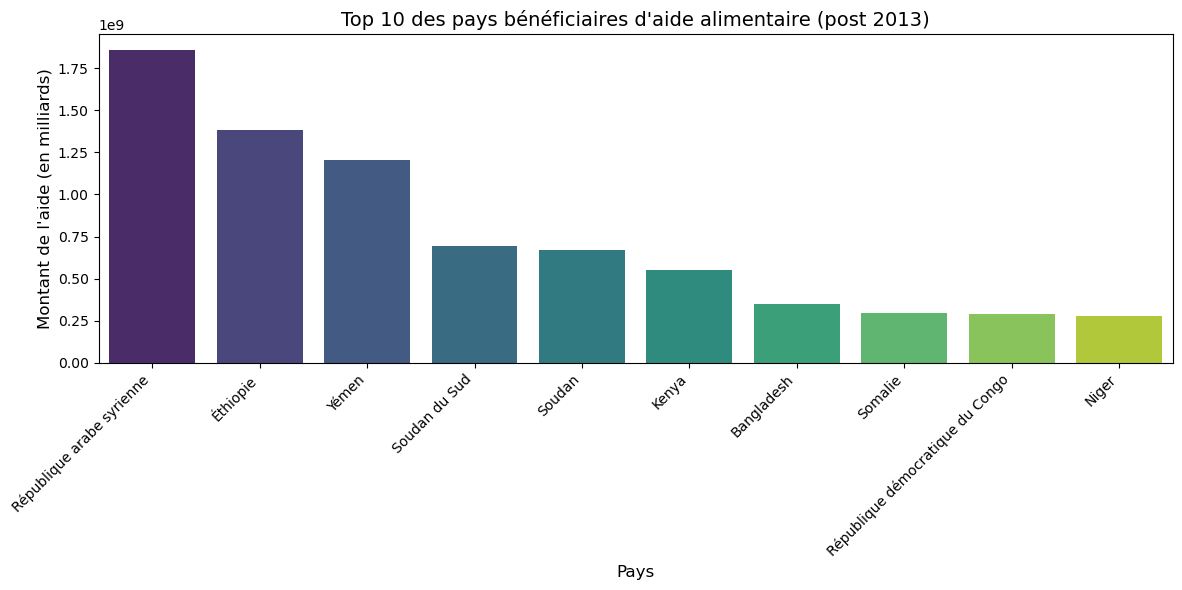

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Données
data = {
    "Zone": ["République arabe syrienne", "Éthiopie", "Yémen", "Soudan du Sud", "Soudan",
             "Kenya", "Bangladesh", "Somalie", "République démocratique du Congo", "Niger"],
    "Valeur": [1858943000, 1381294000, 1206484000, 695248000, 669784000,
               552836000, 348188000, 292678000, 288520000, 276344000]
}

df = pd.DataFrame(data)

# Création du graphique
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Zone", y="Valeur", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 des pays bénéficiaires d'aide alimentaire (post 2013)", fontsize=14)
plt.xlabel("Pays", fontsize=12)
plt.ylabel("Montant de l'aide (en milliards)", fontsize=12)
plt.tight_layout()
plt.show()


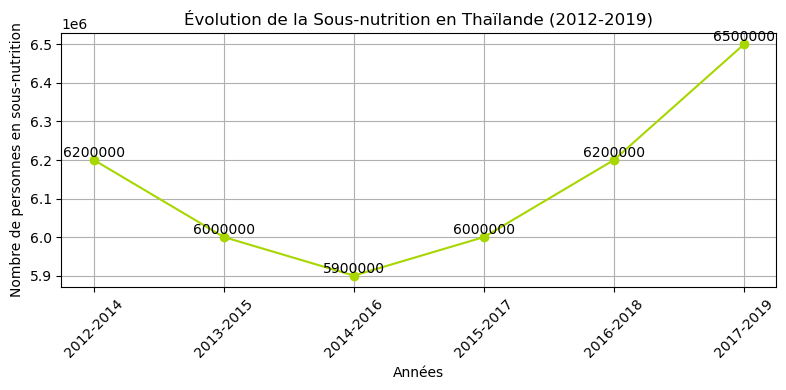

In [124]:
import matplotlib.pyplot as plt

# Données de sous-nutrition pour la Thaïlande
annees = [
    "2012-2014",
    "2013-2015",
    "2014-2016",
    "2015-2017",
    "2016-2018",
    "2017-2019"
]

sous_nutrition = [
    6200000.0,
    6000000.0,
    5900000.0,
    6000000.0,
    6200000.0,
    6500000.0
]

# Représentation graphique
plt.figure(figsize=(8, 4))
plt.plot(annees, sous_nutrition, marker='o', color='#A8D600', linestyle='-')
plt.title("Évolution de la Sous-nutrition en Thaïlande (2012-2019)")
plt.xlabel("Années")
plt.ylabel("Nombre de personnes en sous-nutrition")
plt.xticks(rotation=45)
plt.grid()

# Affichage des valeurs sur la ligne
for i, value in enumerate(sous_nutrition):
    plt.text(i, value, f'{value:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


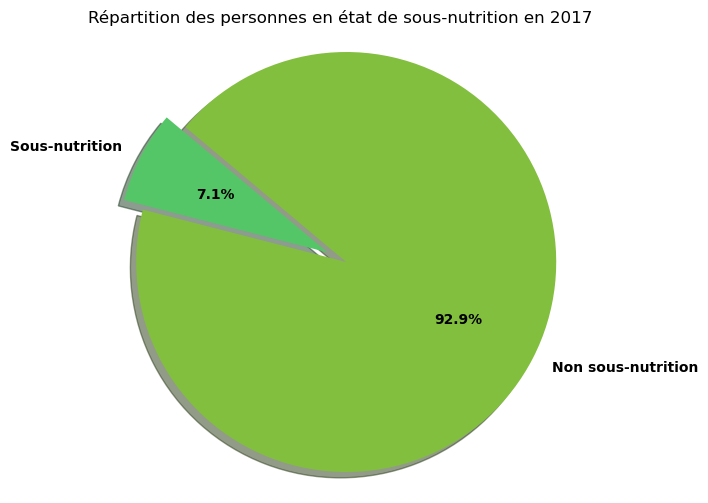

In [125]:
import matplotlib.pyplot as plt

# Données
labels = ['Sous-nutrition', 'Non sous-nutrition']
sizes = [535700000, 7543798779 - 535700000]  # Total population - sous-nutrition
colors = ['#55C667FF', '#83BF3E']
explode = (0.1, 0)  # "exploser" la première tranche

# Création du graphique
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

# Mettre les labels en gras
for label in plt.gca().texts:
    label.set_fontweight('bold')

plt.axis('equal')  # Égaliser l'aspect du graphique
plt.title("Répartition des personnes en état de sous-nutrition en 2017")
plt.show()



In [126]:
liste_cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Orge",
    "Maïs",
    "Seigle",
    "Avoine",
    "Millet",
    "Sorgho",
    "Céréales, Autres"
]

print("Liste des Céréales :\n")
for cereale in liste_cereales:
    print(f"- {cereale}")


Liste des Céréales :

- Blé
- Riz (Eq Blanchi)
- Orge
- Maïs
- Seigle
- Avoine
- Millet
- Sorgho
- Céréales, Autres


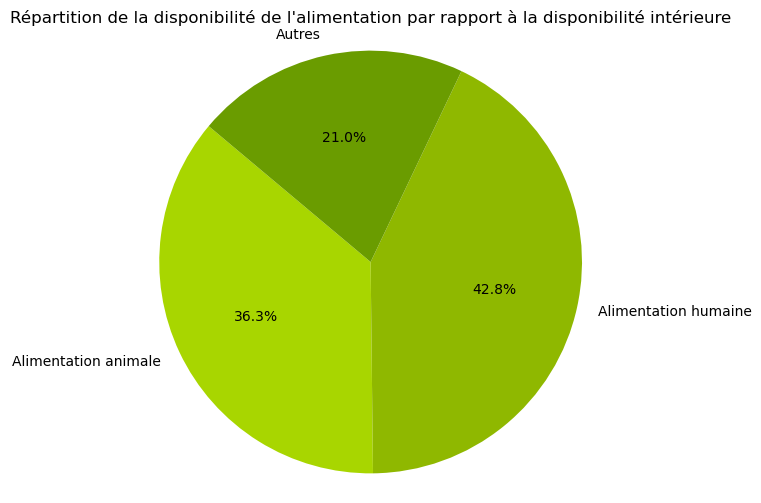

In [127]:
import matplotlib.pyplot as plt

# Données
categories = ['Alimentation animale', 'Alimentation humaine', 'Autres']
disponibilites = [36.29, 42.75, 100 - (36.29 + 42.75)]  # Autres pour compléter à 100%

# Dégradé de couleur vert
colors = ['#A8D600', '#8FB800', '#6A9C00']  # Couleurs dégradées de vert

# Création du graphique
plt.figure(figsize=(6, 6))
plt.pie(disponibilites, labels=categories, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Répartition de la disponibilité de l'alimentation par rapport à la disponibilité intérieure")
plt.axis('equal')  # Pour un camembert circulaire

# Affichage du graphique
plt.show()


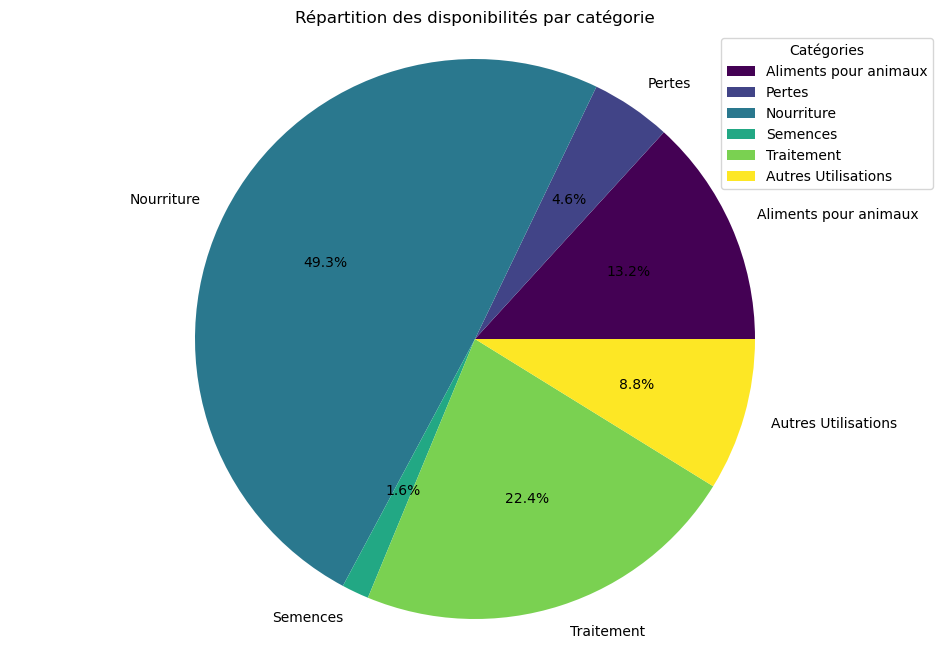

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# Données
categories = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Semences', 'Traitement', 'Autres Utilisations']
proportions = [13.232090, 4.646400, 49.368821, 1.575079, 22.453846, 8.822542]

# Palette de couleurs viridis
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))

# Création du graphique en camembert
plt.figure(figsize=(12, 8))
plt.pie(proportions, labels=categories, autopct='%1.1f%%', colors=colors)
plt.title('Répartition des disponibilités par catégorie')
plt.legend(title="Catégories", loc="upper right")

plt.axis('equal')  # Pour un camembert circulaire
plt.show()


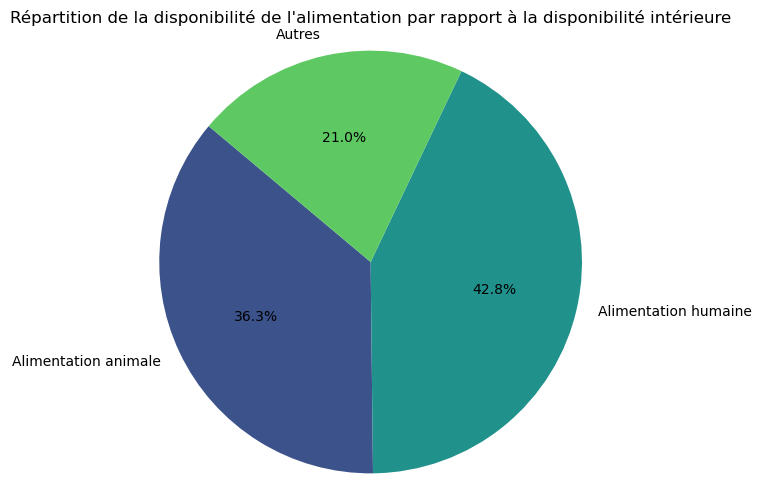

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

# Données
categories = ['Alimentation animale', 'Alimentation humaine', 'Autres']
disponibilites = [36.29, 42.75, 100 - (36.29 + 42.75)]  # Autres pour compléter à 100%

# Palette viridis
colors = sns.color_palette("viridis", n_colors=3)  # Obtenir 3 couleurs de la palette viridis

# Création du graphique
plt.figure(figsize=(6, 6))
plt.pie(disponibilites, labels=categories, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Répartition de la disponibilité de l'alimentation par rapport à la disponibilité intérieure")
plt.axis('equal')  # Pour un camembert circulaire

# Affichage du graphique
plt.show()


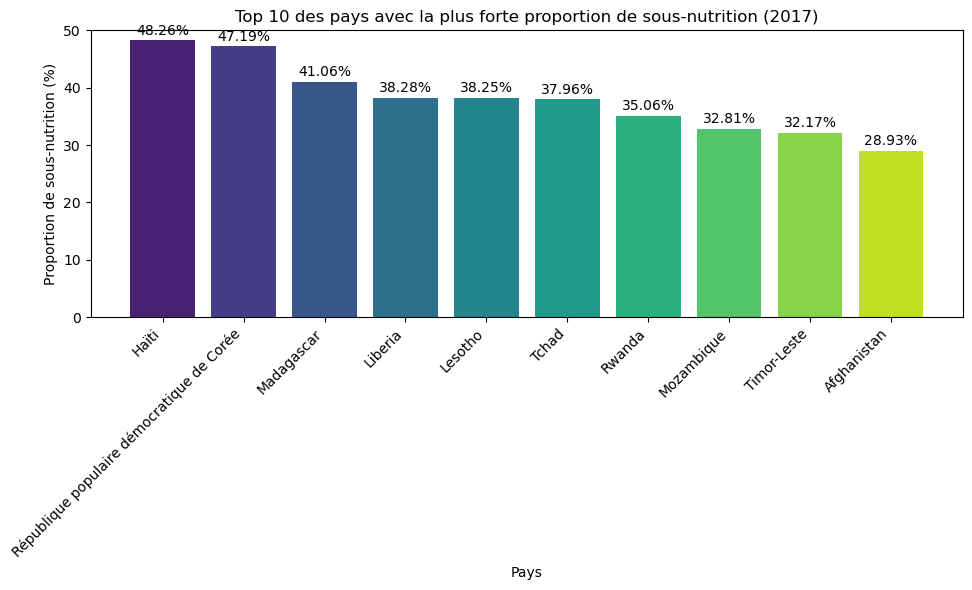

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

# Données des 10 pires pays en termes de proportion de sous-nutrition
pays = [
    "Haïti",
    "République populaire démocratique de Corée",
    "Madagascar",
    "Liberia",
    "Lesotho",
    "Tchad",
    "Rwanda",
    "Mozambique",
    "Timor-Leste",
    "Afghanistan"
]

proportions = [
    48.259182,
    47.188685,
    41.062924,
    38.279742,
    38.249438,
    37.957606,
    35.055619,
    32.810898,
    32.173531,
    28.928718
]

# Palette viridis
colors = sns.color_palette("viridis", n_colors=len(pays))

# Représentation graphique
plt.figure(figsize=(10, 6))
plt.bar(pays, proportions, color=colors)
plt.title("Top 10 des pays avec la plus forte proportion de sous-nutrition (2017)")
plt.ylabel("Proportion de sous-nutrition (%)")
plt.xlabel("Pays")
plt.ylim(0, 50)  # Limite de l'axe y pour une meilleure visualisation
#plt.grid(axis='y')

# Affichage des valeurs sur les barres
for index, value in enumerate(proportions):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center')

plt.xticks(rotation=45, ha='right')  # Rotation des étiquettes pour une meilleure lisibilité
plt.tight_layout()
plt.show()


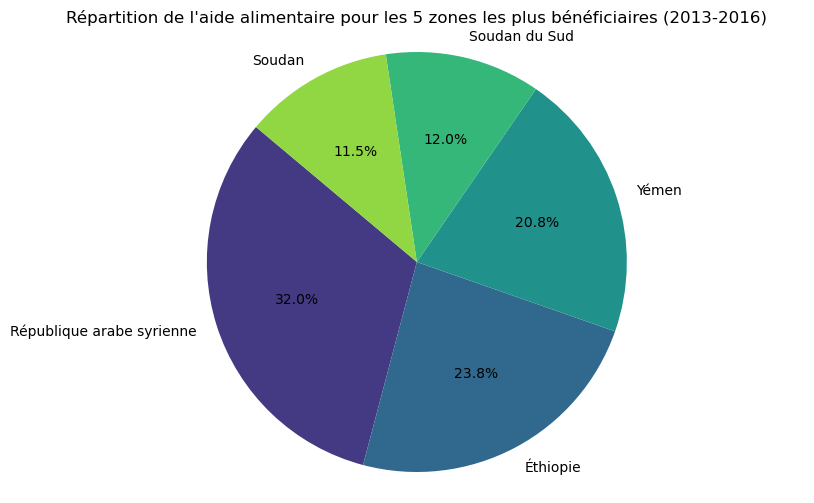

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtenir les 5 zones avec les valeurs les plus élevées
top_5_zones = Plus_bénéficiés.groupby('Zone')['Valeur'].sum().nlargest(5)

# Palette viridis
colors = sns.color_palette("viridis", n_colors=len(top_5_zones))

# Création du graphique en camembert
plt.figure(figsize=(10, 6))
plt.pie(top_5_zones, labels=top_5_zones.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Répartition de l\'aide alimentaire pour les 5 zones les plus bénéficiaires (2013-2016)')
plt.axis('equal')  # Pour un camembert circulaire
plt.show()
